In [4]:
import matplotlib.pyplot as plt
import pickle
import votekit.ballot_generator as blt_gen
from votekit import PreferenceInterval
from votekit.metrics import lp_dist, earth_mover_dist
from votekit.plots import plot_MDS, compute_MDS
from joblib import Parallel, delayed
from functools import partial
from peter_slate_emd import *
from slate_emd import score_vec_from_slate_tuple

In [10]:
print(score_vec_from_slate_tuple(('w','x','y','z','r'), {"A": ['x','r','w'], "B": ['z','y']},5))
print(score_vec_from_slate_tuple(('w','r','y','z','x'), {"A": ['x','r','w'], "B": ['z','y']},5))
print(score_vec_from_slate_tuple(('w','x','z','y','r'), {"A": ['x','r','w'], "B": ['z','y']},5))

[5 4 1 3 2]
[5 4 1 3 2]
[5 4 1 3 2]


In [2]:
from optimize_helper import *

In [3]:
b_bloc_party_dict = {
    ("aberdeen", 2017, 11): [
        "Labour (Lab)",
        "Scottish National Party (SNP)",
        "Liberal Democrat (LD)",
    ],
    ("aberdeen", 2022, 11): ["Conservative and Unionist Party (Con)", "Labour (Lab)"],
    ("aberdeen", 2017, 10): ["Conservative and Unionist Party (Con)"],
}

file_names = {
    ("aberdeen", 2017, 11): "../election_data/aberdeen_2017_ward11.csv",
    ("aberdeen", 2022, 11): "../election_data/aberdeen_2022_ward11.csv",
    ("aberdeen", 2017, 10): "../election_data/aberdeen_2017_ward10.csv",
}


models_to_gen = {
    "n-BT": blt_gen.name_BradleyTerry,
    "n-PL": blt_gen.name_PlackettLuce,
    "s-BT": blt_gen.slate_BradleyTerry,
    "s-PL": blt_gen.slate_PlackettLuce,
    "CS-C": blt_gen.CambridgeSampler,
    "CS-W": blt_gen.CambridgeSampler,
    "solid": 0,
    "IC": blt_gen.ImpartialCulture,
    "IAC": blt_gen.ImpartialAnonymousCulture,
}

new_models = ["CS-C", "CS-W", "n-BT", "n-PL", "s-BT", "s-PL"]
old_models = ["solid", "IC", "IAC"]
scottish_color = ["#1560BD"]
model_to_color = {
    'CS-C': '#D2691E', 
    'CS-W': '#E32636', 
    'n-BT': '#8B008B', 
    'n-PL': '#FFB7C5', 
    's-BT': '#FFBF00', 
    's-PL': '#8DB600',
    "solid":"#09FCEE",
    "scottish": "#1560BD", 
    "IC":"#1A7601",
    "IAC":"#929292" 
}

In [4]:
def set_up_bg(
    model_str, 
    models,
    model_parameters, 
    slate_to_candidates, 
    cand_to_bloc,
    bloc_voter_prop, 
    cohesion_parameters, 
    alphas
):
    bg = None
    if model_str not in ["n-BT", "n-PL", "solid", "IC", "IAC"]:
        if "CS" in model_str:
            if model_str == "CS-W":
                bg = models[model_str].from_params(
                    slate_to_candidates,
                    bloc_voter_prop,
                    cohesion_parameters,
                    alphas,
                    W_bloc="B",
                    C_bloc="A",
                )
            else:
                bg = models[model_str].from_params(
                    slate_to_candidates,
                    bloc_voter_prop,
                    cohesion_parameters,
                    alphas,
                    W_bloc="A",
                    C_bloc="B",
                )
        else:
            bg = models[model_str].from_params(
                slate_to_candidates,
                bloc_voter_prop,
                cohesion_parameters,
                alphas,
            )
    elif model_str not in ["solid", "IC", "IAC"]:
        candidates = []
        for c_list in slate_to_candidates.values():
            candidates += c_list

        aa_interval = {
            f"A_{i}": p
            for i, p in enumerate(model_parameters["pref_intervals"]["A"]["A"].values())
        }
        ab_interval = {
            f"B_{i}": p
            for i, p in enumerate(model_parameters["pref_intervals"]["A"]["B"].values())
        }

        ba_interval = {
            f"A_{i}": p
            for i, p in enumerate(model_parameters["pref_intervals"]["B"]["A"].values())
        }
        bb_interval = {
            f"B_{i}": p
            for i, p in enumerate(model_parameters["pref_intervals"]["B"]["B"].values())
        }

        pref_intervals_by_bloc = {
            "A": {
                "A": PreferenceInterval(aa_interval),
                "B": PreferenceInterval(ab_interval),
            },
            "B": {
                "A": PreferenceInterval(ba_interval),
                "B": PreferenceInterval(bb_interval),
            },
        }
        bg = models[model_str](
            candidates=candidates,
            cohesion_parameters=cohesion_parameters,
            bloc_voter_prop=bloc_voter_prop,
            pref_intervals_by_bloc=pref_intervals_by_bloc,
        )

    elif model_str in ["IC", "IAC"]:
        bg = models_to_gen[model_str](candidates = list(cand_to_bloc.keys())) 

    elif model_str == "solid":
        bg=None

    else:
        raise ValueError("invalid model string")

    return bg

In [5]:
def make_profile(
    model_str,
    bg,
    slate_scottish_profile,
    pi_a,
    pi_b,
    bloc_to_cand_num,
    bloc_voter_prop,
    n_ballots = 10000,
    MCMC_sample_size = 10000,
):
    if sum(bloc_to_cand_num.values()) >= 12 and model_str in [
        "n-BT",
        "s-BT",
    ]:
        if model_str == "n-BT":
            profile = bg.generate_profile_MCMC(MCMC_sample_size)
        else:
            profile = bg.generate_profile(
                MCMC_sample_size, deterministic=False
            )

    elif model_str == "solid":
    
        solid_profile_b = generate_solid_profile(
            pi_b,
            int(bloc_voter_prop["B"] * n_ballots),
            bloc_to_cand_num,
        )
        solid_profile_a = generate_solid_profile(
            pi_a,
            int(bloc_voter_prop["A"] * n_ballots),
            bloc_to_cand_num,
        )
        profile = solid_profile_a + solid_profile_b
    else:
        # try:
        profile = bg.generate_profile(n_ballots)
        # except Exception as e:
        #     print(
        #         f"Tried to generate profile for {model_str} with {pi_a} {pi_b} and "
        #     )
    return profile

In [6]:
def anonymize_slates(prefp, cand_list, cand_to_party, b_bloc_parties):
    cand_to_anon = {}

    a_count = 0
    b_count = 0
    for c in cand_list:
        if cand_to_party[c] in b_bloc_parties:
            cand_to_anon[c] = f"B_{b_count}"
            b_count += 1
        else:
            cand_to_anon[c] = f"A_{a_count}"
            a_count += 1

    bal = prefp.ballots[0]
    all_new_ballots = []
    for bal in prefp.ballots:
        for c in bal.ranking:
            if len(c) > 1:
                raise ValueError("Ties must be resolved before anonymizing")
            new_bal = Ballot(
                ranking=[{cand_to_anon[list(c)[0]]} for c in bal.ranking],
                weight=bal.weight,
            )
            all_new_ballots.append(new_bal)

    all_new_ballots
    new_pref_prof = PreferenceProfile(ballots=all_new_ballots)
    return new_pref_prof



In [17]:
# MCMC_sample_size = 10000

# ward_to_profile = {}

# base_pickle_name = "distance_data/2_bloc/emd_to_scottish_{ward_label}_two_bloc_optimized_{model_str}_bloc_order_AB.pkl"


# check_file = "prof_check_2_bloc.log"
# with open(check_file, "w") as f:
#     pass

# for key, file_name in list(file_names.items())[:]:
#     b_bloc_parties = b_bloc_party_dict[key]
#     city, year, ward = key
    
#     temp_old_models = old_models
    
#     ward_label = f"{city} ward_{ward} {year}"
#     print(f"Processing {ward_label}")
  
#     # Estimate model parameters
#     model_parameters = peter_estimate_2_bloc_parameters(file_name, b_bloc_parties)


#     scottish_profile, num_seats, cand_list, cand_to_party, ward = load_scottish(
#         file_name,
#     )


#     slate_scottish_profile = anonymize_slates(
#         scottish_profile,
#         cand_list,
#         cand_to_party,
#         b_bloc_parties,
#     )

#     cand_to_bloc = {
#         c: "B" if cand_to_party[c] in b_bloc_parties else "A"
#         for c in cand_list
#     }

#     # count the number of candidates in each bloc
#     bloc_to_cand_num = {
#         "A": len([c for c, bloc in cand_to_bloc.items() if bloc == "A"]),
#         "B": len([c for c, bloc in cand_to_bloc.items() if bloc == "B"]),
#     }

#     # try a one bloc model, where cohesion is percentage of first place votes
#     slate_to_candidates = {
#         b: [f"{b}_{i}" for i in range(bloc_to_cand_num[b])]
#         for b in bloc_to_cand_num.keys()
#     }
#     cand_to_bloc = {c: b for b, c_list in slate_to_candidates.items() for c in c_list}

#     bloc_voter_prop = {
#         "A": model_parameters["bloc_first"]["A"],
#         "B": model_parameters["bloc_first"]["B"],
#     }
    
#     profile_lists = {}
#     model_list = temp_old_models+new_models
   
#     for model_str in model_list:
#         print(f"Processing {model_str}")
        
#         with open(base_pickle_name.format(
#             ward_label=ward_label, 
#             model_str=model_str, 
#             b_bloc_parties=b_bloc_parties, 
#         ), "rb") as f:
#             min_pi_a, min_pi_b = pickle.load(f)
#             if min_pi_a == "N/A" or min_pi_b == "N/A":
#                 min_pi_a, min_pi_b = 0,0
        
#         cohesion_parameters = {
#             "A": {"A": min_pi_a, "B": 1-min_pi_a},
#             "B": {"B": min_pi_b, "A": 1-min_pi_b}
#         }
        
#         alphas = {
#             "A": {"A": 1, "B": 1},
#             "B": {"B": 1, "A": 1}
#         }
        
#         bg = set_up_bg(
#             model_str, 
#             models_to_gen,
#             model_parameters, 
#             slate_to_candidates, 
#             cand_to_bloc,
#             bloc_voter_prop, 
#             cohesion_parameters, 
#             alphas
#         )
        

#         n_profiles = 100

#         parallel_profile_function = partial(
#             make_profile,
#             model_str=model_str,
#             bg=bg,
#             slate_scottish_profile=slate_scottish_profile,
#             pi_a=min_pi_a,
#             pi_b=min_pi_b,
#             bloc_to_cand_num=bloc_to_cand_num,
#             bloc_voter_prop=bloc_voter_prop,
#             MCMC_sample_size=MCMC_sample_size,
#         )


#         n_jobs = -1
#         profiles = Parallel(n_jobs=n_jobs)(delayed(parallel_profile_function)() for _ in range(n_profiles))
           
#         with open(check_file, "a") as f:
#             for profile in profiles:
#                 f.write(f"{model_str}\n\t{profile.head(3)}\n")
#         profile_lists[model_str]=profiles
#     ward_to_profile[ward_label] = profile_lists

Processing aberdeen ward_11 2017
Processing solid
Processing IC
Processing IAC
Processing CS-C
Processing CS-W
Processing n-BT
Processing n-PL
Processing s-BT
Processing s-PL
Processing aberdeen ward_11 2022
Processing solid
Processing IC
Processing IAC
Processing CS-C
Processing CS-W
Processing n-BT
Processing n-PL
Processing s-BT
Processing s-PL
Processing aberdeen ward_10 2017
Processing solid
Processing IC
Processing IAC
Processing CS-C
Processing CS-W
Processing n-BT
Processing n-PL
Processing s-BT
Processing s-PL


In [21]:
# with open("ward_prof_emd_tmp_2_bloc.pkl", "wb") as f:
#     pickle.dump(ward_to_profile, f)
    
ward_to_profile = {}
with open("ward_prof_emd_tmp_2_bloc.pkl", "rb") as f:
    ward_to_profile = pickle.load(f)

In [19]:
ward_to_profile['aberdeen ward_11 2017']["IC"][0]

PreferenceProfile too long, only showing 15 out of 24 rows.


             Ballots Weight
(B_0, A_0, B_1, B_2)    662
(B_2, A_0, B_0, B_1)    659
(B_0, A_0, B_2, B_1)    653
(B_1, B_2, B_0, A_0)    652
(A_0, B_1, B_2, B_0)    648
(B_1, A_0, B_2, B_0)    646
(B_1, A_0, B_0, B_2)    646
(B_0, B_2, A_0, B_1)    644
(B_0, B_1, A_0, B_2)    638
(B_2, B_0, A_0, B_1)    632
(B_2, B_1, B_0, A_0)    629
(A_0, B_0, B_1, B_2)    626
(B_2, A_0, B_1, B_0)    620
(B_1, B_0, A_0, B_2)    619
(B_2, B_0, B_1, A_0)    615

In [22]:
# ward_to_coords = {}
# sp = None
# for key, file_name in list(file_names.items())[:]: 
#     print(key)
#     city, year, ward = key

#     ward_label = f"{city} ward_{ward} {year}"

#     scottish_profile, _, cand_list, cand_to_party, _ = load_scottish(file_name)


#     scottish_profile = anonymize_slates(scottish_profile, cand_list, cand_to_party, b_bloc_party_dict[key])
   
#     # the data is a dictionary whose keys correspond to data labels
#     # and whose values are lists of PreferenceProfiles
#     data =  {model_str:profiles[:] for model_str, profiles in ward_to_profile[ward_label].items()}

#     data.update({"scottish":[scottish_profile]})

#     n_b_cands = sum(cand_to_party[c] in b_bloc_party_dict[key] for c in cand_list)
#     n_a_cands = len(cand_list) - n_b_cands
    
#     slate_dict = {
#         "A": [f"A_{i}" for i in range(n_a_cands)],
#         "B": [f"B_{i}" for i in range(n_b_cands)],
#     }
#     slate_emd = partial(slate_earth_mover_dist, slate_dict=slate_dict)
#     coord_dict = compute_MDS(
#         data =data, 
#         distance = slate_emd,
#         random_seed=47
#     )
    
#     ward_to_coords[ward_label]=coord_dict

('aberdeen', 2017, 11)


  0%|          | 0/901 [00:00<?, ?it/s]

100%|██████████| 901/901 [06:48<00:00,  2.20it/s]


('aberdeen', 2022, 11)


100%|██████████| 901/901 [26:03<00:00,  1.74s/it]


('aberdeen', 2017, 10)


100%|██████████| 901/901 [1:26:50<00:00,  5.78s/it]  


In [23]:
# with open("ward_to_coords_emd_opt_2_bloc.pkl", "wb") as f:
    # pickle.dump(ward_to_coords, f)
    
ward_to_coords = pickle.load(open("ward_to_coords_emd_opt_2_bloc.pkl", "rb"))

In [26]:
for key, val in ward_to_coords.items():
    ward_to_coords[key] = dict(reversed(list(val.items())))

In [27]:
len(ward_to_coords['aberdeen ward_10 2017']["n-PL"][0])

100

aberdeen ward_11 2017


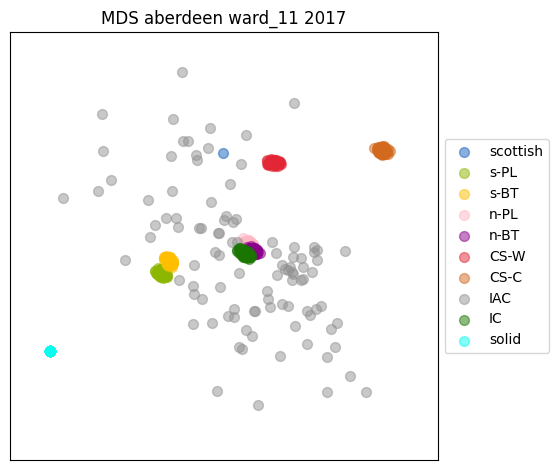

aberdeen ward_11 2022


<Figure size 640x480 with 0 Axes>

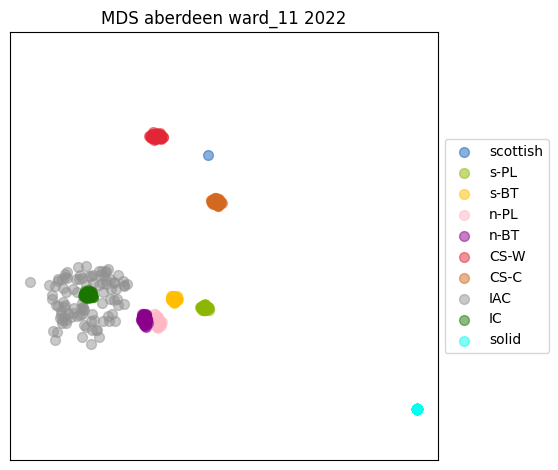

aberdeen ward_10 2017


<Figure size 640x480 with 0 Axes>

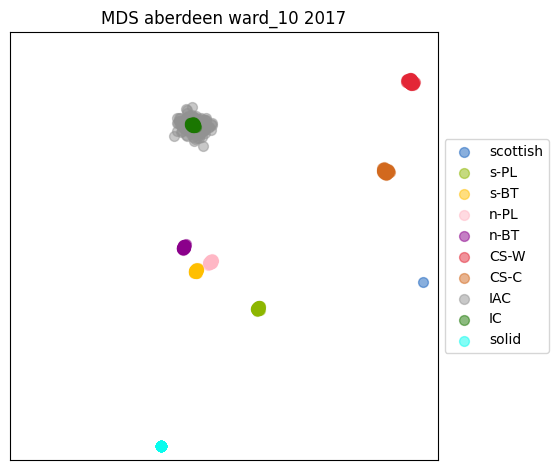

<Figure size 640x480 with 0 Axes>

In [28]:
# for key, file_name in [(("aberdeen", 2022, 11), "../election_data/aberdeen_2022_ward11.csv")]:
for key, file_name in list(file_names.items())[:]:  
    city, year, ward = key
    
    ward_label = f"{city} ward_{ward} {year}"
    print(ward_label)
    plot_kwarg_dict={m:{"c":color, "s":50, "alpha": 0.5 } for m, color in model_to_color.items()}
    plot_kwarg_dict.update({ward_label: {"c": scottish_color, "s":50}})
    
    ax = plot_MDS(coord_dict=ward_to_coords[ward_label], 
                    plot_kwarg_dict=plot_kwarg_dict,
                    legend = True, title = True)
    
    ax.legend(bbox_to_anchor=(1, .5), loc="center left")
    plt.title(f"MDS {ward_label}")
    plt.tight_layout()
    plt.show()
    plt.savefig(f"figures/MDS/emd_opt_mds_{ward_label.replace(' ', '_')}_2_bloc.png",bbox_inches='tight', dpi=300)
    plt.clf()

In [29]:
for key, file_name in file_names.items():
    scottish_profile, num_seats, cand_list, cand_to_party, ward = load_scottish(file_name)
    print(scottish_profile.num_ballots(), num_seats, len(cand_list))

6116 3 4
5872 3 5
7508 4 6


: 